In [11]:
from preprocessing.preprocess import preprocess

# For Decision Tree, 'flatten' is the most standard way to start
X_train, X_val, X_test, y_train, y_val, y_test = preprocess(
    feature_method='flatten',
    binary=True,
    positive_class=1
)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")


 Starting Preprocessing Pipeline...
   Feature method : flatten
   Mode           : Binary

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Labels encoded — Positive class: Digit 1
   Training — Positive samples : 6742
   Training — Negative samples : 53258
   Test     — Positive samples : 1135
   Test     — Negative samples : 8865

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using FLATTEN...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : 0.0000
   Training std  (should be ~1) : 0.9536

 Preprocessing Pipeline Complete!
   X_tr   :

In [12]:
# ============================================================
# Cell 3: Decision Tree Classifier — Implemented from Scratch
# Binary Classification on MNIST (Gini Index)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import time

# ─────────────────────────────────────────────
# Node Structure
# ─────────────────────────────────────────────
class Node:
    def __init__(self, feature=None, threshold=None,
                 left=None, right=None, *, value=None):
        self.feature   = feature
        self.threshold = threshold
        self.left      = left
        self.right     = right
        self.value     = value

    def is_leaf(self):
        return self.value is not None


# ─────────────────────────────────────────────
# Vectorized Best Split (Gini Index)
# ─────────────────────────────────────────────
def best_split_fast(X, y):
    """
    For each feature, sort samples once then use prefix sums
    to evaluate ALL thresholds in one vectorized pass.
    Gini(D) = 1 - sum(p_k^2)
    Weighted Gini = (|L|/|D|)*Gini(L) + (|R|/|D|)*Gini(R)
    """
    n_samples, n_features = X.shape
    n_pos_total = np.sum(y == 1)
    best_feature, best_threshold, best_gini_val = None, None, float('inf')

    for feat_idx in range(n_features):
        col        = X[:, feat_idx]
        order      = np.argsort(col, kind='mergesort')
        col_sorted = col[order]
        y_sorted   = y[order]

        # Prefix sums — count positives on the left at every cut point
        cum_pos = np.cumsum(y_sorted == 1)
        cum_n   = np.arange(1, n_samples + 1)

        left_pos  = cum_pos[:-1]
        left_n    = cum_n[:-1]
        right_pos = n_pos_total - left_pos
        right_n   = n_samples   - left_n

        # Only consider cuts where the feature value actually changes
        valid = col_sorted[:-1] != col_sorted[1:]
        if not np.any(valid):
            continue

        left_pos  = left_pos[valid];  left_n  = left_n[valid]
        right_pos = right_pos[valid]; right_n = right_n[valid]

        # Vectorized Gini for all valid thresholds at once
        p_left  = left_pos  / left_n
        p_right = right_pos / right_n

        gini_left  = 1.0 - (p_left**2  + (1 - p_left)**2)
        gini_right = 1.0 - (p_right**2 + (1 - p_right)**2)
        weighted   = (left_n * gini_left + right_n * gini_right) / n_samples

        best_idx = np.argmin(weighted)
        if weighted[best_idx] < best_gini_val:
            best_gini_val  = weighted[best_idx]
            best_feature   = feat_idx
            cut            = np.where(valid)[0][best_idx]
            best_threshold = (col_sorted[cut] + col_sorted[cut + 1]) / 2.0

    return best_feature, best_threshold, best_gini_val


# ─────────────────────────────────────────────
# Recursive Tree Builder
# ─────────────────────────────────────────────
def build_tree(X, y, depth=0, max_depth=15, min_samples_split=10):
    """
    Stopping conditions:
      1. Pure node (all same class)
      2. Reached max_depth
      3. Too few samples to split
    Leaf value = majority class (argmax of bincount)
    """
    n_classes = len(np.unique(y))

    if (n_classes == 1) or (depth >= max_depth) or (len(y) < min_samples_split):
        return Node(value=int(np.bincount(y).argmax()))

    feat, thresh, _ = best_split_fast(X, y)

    if feat is None:
        return Node(value=int(np.bincount(y).argmax()))

    left_mask  = X[:, feat] <= thresh
    right_mask = ~left_mask

    return Node(
        feature   = feat,
        threshold = thresh,
        left  = build_tree(X[left_mask],  y[left_mask],  depth+1, max_depth, min_samples_split),
        right = build_tree(X[right_mask], y[right_mask], depth+1, max_depth, min_samples_split)
    )


# ─────────────────────────────────────────────
# Prediction (iterative — avoids recursion limit)
# ─────────────────────────────────────────────
def predict_one(tree, x):
    node = tree
    while not node.is_leaf():
        node = node.left if x[node.feature] <= node.threshold else node.right
    return node.value

def predict(tree, X):
    return np.array([predict_one(tree, x) for x in X])


print("✅ Cell 3 complete — Decision Tree defined successfully.")

✅ Cell 3 complete — Decision Tree defined successfully.


In [13]:
# ============================================================
# Train Decision Tree
# ============================================================

MAX_DEPTH         = 15
MIN_SAMPLES_SPLIT = 10

print("=" * 55)
print("  TRAINING DECISION TREE")
print("=" * 55)
print(f"   max_depth         : {MAX_DEPTH}")
print(f"   min_samples_split : {MIN_SAMPLES_SPLIT}")
print(f"   training samples  : {X_train.shape[0]}")
print(f"   features          : {X_train.shape[1]}")

t0   = time.time()
tree = build_tree(X_train, y_train, max_depth=MAX_DEPTH, min_samples_split=MIN_SAMPLES_SPLIT)
t1   = time.time()

print(f"\n✅ Tree built successfully in {t1 - t0:.1f} seconds!")

  TRAINING DECISION TREE
   max_depth         : 15
   min_samples_split : 10
   training samples  : 48000
   features          : 784

✅ Tree built successfully in 38.1 seconds!


       EVALUATION — FLATTEN

📊 Validation Set — Flatten
   Accuracy  : 98.62%
   Precision : 93.40%
   Recall    : 94.18%
   F1-Score  : 93.79%
   TP=1245  TN=10590  FP=88  FN=77


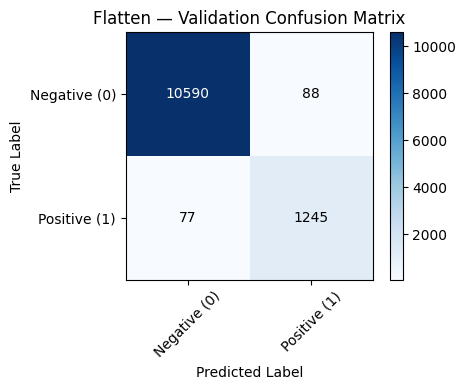


📊 Test Set — Flatten
   Accuracy  : 98.99%
   Precision : 95.51%
   Recall    : 95.59%
   F1-Score  : 95.55%
   TP=1085  TN=8814  FP=51  FN=50


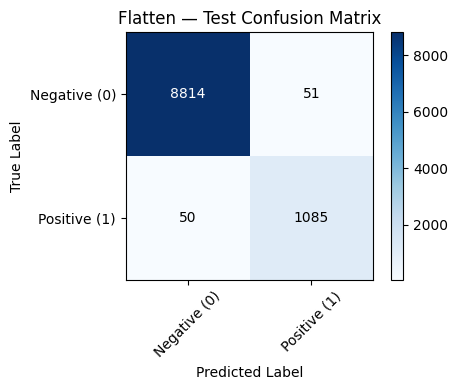


⚖️  Baseline (predict all-negative) : 88.65%
   Decision Tree Test Accuracy     : 98.99%
   Improvement over baseline       : +10.34%

   Val/Test accuracy gap           : 0.37%
   (healthy if < 2%)

✅ Cell 5 complete — Flatten Evaluation done!


In [14]:
# ============================================================
# Cell 5: Evaluation — Metrics & Confusion Matrix
# ============================================================

# ─────────────────────────────────────────────
# Metrics (all from scratch)
# ─────────────────────────────────────────────
def compute_metrics(y_true, y_pred):
    TP = int(np.sum((y_pred == 1) & (y_true == 1)))
    TN = int(np.sum((y_pred == 0) & (y_true == 0)))
    FP = int(np.sum((y_pred == 1) & (y_true == 0)))
    FN = int(np.sum((y_pred == 0) & (y_true == 1)))

    accuracy  = (TP + TN) / len(y_true)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)

    return {
        'accuracy' : round(accuracy,  4),
        'precision': round(precision, 4),
        'recall'   : round(recall,    4),
        'f1'       : round(f1,        4),
        'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN
    }


def print_metrics(metrics, split_name):
    print(f"\n📊 {split_name}")
    print(f"   Accuracy  : {metrics['accuracy']  * 100:.2f}%")
    print(f"   Precision : {metrics['precision'] * 100:.2f}%")
    print(f"   Recall    : {metrics['recall']    * 100:.2f}%")
    print(f"   F1-Score  : {metrics['f1']        * 100:.2f}%")
    print(f"   TP={metrics['TP']}  TN={metrics['TN']}  FP={metrics['FP']}  FN={metrics['FN']}")


def plot_confusion_matrix(metrics, title="Confusion Matrix"):
    cm = np.array([[metrics['TN'], metrics['FP']],
                   [metrics['FN'], metrics['TP']]])
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)
    classes = ['Negative (0)', 'Positive (1)']
    ax.set_xticks([0, 1]); ax.set_xticklabels(classes, rotation=45)
    ax.set_yticks([0, 1]); ax.set_yticklabels(classes)
    thresh_color = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > thresh_color else 'black')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────
# Run Evaluation on Full Sets
# ─────────────────────────────────────────────
print("=" * 55)
print("       EVALUATION — FLATTEN")
print("=" * 55)

y_val_pred  = predict(tree, X_val)
y_test_pred = predict(tree, X_test)

val_metrics_flat  = compute_metrics(y_val,  y_val_pred)   # ← renamed
test_metrics_flat = compute_metrics(y_test, y_test_pred)  # ← renamed

print_metrics(val_metrics_flat,  "Validation Set — Flatten")
plot_confusion_matrix(val_metrics_flat,  title="Flatten — Validation Confusion Matrix")

print_metrics(test_metrics_flat, "Test Set — Flatten")
plot_confusion_matrix(test_metrics_flat, title="Flatten — Test Confusion Matrix")

baseline = np.mean(y_test == 0) * 100
print(f"\n⚖️  Baseline (predict all-negative) : {baseline:.2f}%")
print(f"   Decision Tree Test Accuracy     : {test_metrics_flat['accuracy'] * 100:.2f}%")
print(f"   Improvement over baseline       : +{test_metrics_flat['accuracy'] * 100 - baseline:.2f}%")

gap = abs(val_metrics_flat['accuracy'] - test_metrics_flat['accuracy']) * 100
print(f"\n   Val/Test accuracy gap           : {gap:.2f}%")
print("   (healthy if < 2%)")

print("\n✅ Cell 5 complete — Flatten Evaluation done!")

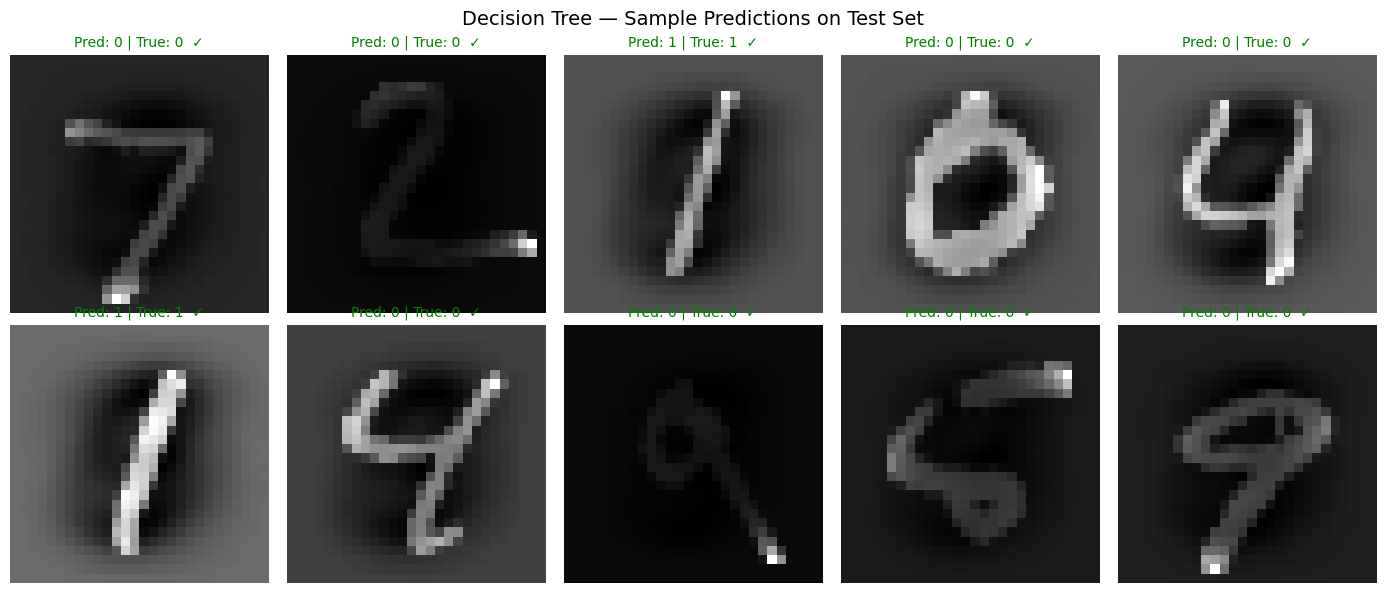


✅ Cell 6 complete — Visual check done!


In [15]:
# ============================================================
# Cell 6: Visual Verification — Sample Predictions
# ============================================================

n_show = 10
X_vis      = X_test[:n_show]
y_vis      = y_test[:n_show]
y_pred_vis = predict(tree, X_vis)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Decision Tree — Sample Predictions on Test Set", fontsize=14)

for i, ax in enumerate(axes.flatten()):
    # Rescale standardized values back to [0,1] for display
    img = X_vis[i].reshape(28, 28)
    img = (img - img.min()) / (img.max() - img.min())

    ax.imshow(img, cmap='gray')

    correct = y_pred_vis[i] == y_vis[i]
    color   = 'green' if correct else 'red'
    label   = '✓' if correct else '✗'

    ax.set_title(
        f"Pred: {y_pred_vis[i]} | True: {y_vis[i]}  {label}",
        color=color, fontsize=10
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Cell 6 complete — Visual check done!")

 Starting Preprocessing Pipeline...
   Feature method : pca
   Mode           : Binary

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Labels encoded — Positive class: Digit 1
   Training — Positive samples : 6742
   Training — Negative samples : 53258
   Test     — Positive samples : 1135
   Test     — Negative samples : 8865

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using PCA...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)
PCA applied successfully!
   Components kept    : 50
   Training shape     : (60000, 50)
   Test shape         : (10000, 50)
   Variance explained : 82.46%

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standar

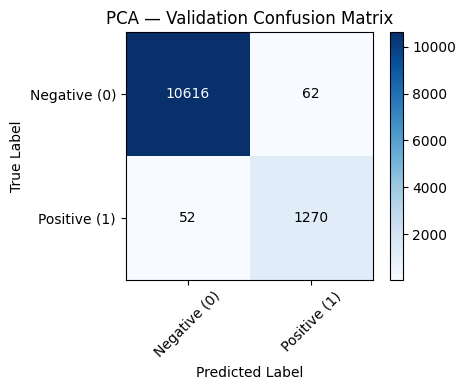


📊 Test Set — PCA
   Accuracy  : 99.22%
   Precision : 96.65%
   Recall    : 96.48%
   F1-Score  : 96.56%
   TP=1095  TN=8827  FP=38  FN=40


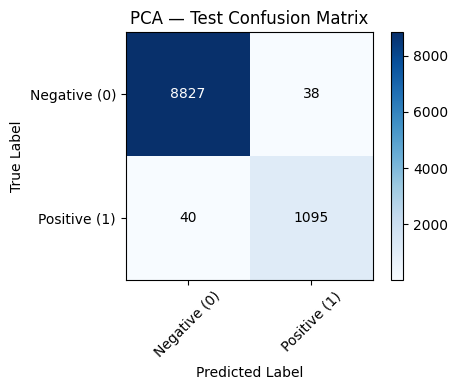


⚖️  Baseline        : 88.65%
   PCA Test Acc   : 99.22%
   Improvement    : +10.57%

✅ PCA cell complete!


In [16]:
# ============================================================
# Decision Tree — Feature Method: PCA (cell 7)
# ============================================================

from preprocessing.preprocess import preprocess

# Load data with PCA feature extraction (50 components)
X_train, X_val, X_test, y_train, y_val, y_test = preprocess(
    feature_method='pca',
    binary=True,
    positive_class=1,
    pca_components=50
)

print(f"Training set  : {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set      : {X_test.shape}")

# ── Train ──────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  TRAINING — PCA Features")
print("=" * 55)

t0       = time.time()
tree_pca = build_tree(X_train, y_train, max_depth=15, min_samples_split=10)
t1       = time.time()
print(f"✅ Tree built in {(t1 - t0) / 60:.1f} minutes!")

# ── Evaluate ───────────────────────────────────────────────
print("\n" + "=" * 55)
print("  EVALUATION — PCA Features")
print("=" * 55)

y_val_pred_pca  = predict(tree_pca, X_val)
y_test_pred_pca = predict(tree_pca, X_test)

val_metrics_pca  = compute_metrics(y_val,  y_val_pred_pca)
test_metrics_pca = compute_metrics(y_test, y_test_pred_pca)

print_metrics(val_metrics_pca,  "Validation Set — PCA")
plot_confusion_matrix(val_metrics_pca,  title="PCA — Validation Confusion Matrix")

print_metrics(test_metrics_pca, "Test Set — PCA")
plot_confusion_matrix(test_metrics_pca, title="PCA — Test Confusion Matrix")

baseline = np.mean(y_test == 0) * 100
print(f"\n⚖️  Baseline        : {baseline:.2f}%")
print(f"   PCA Test Acc   : {test_metrics_pca['accuracy'] * 100:.2f}%")
print(f"   Improvement    : +{test_metrics_pca['accuracy'] * 100 - baseline:.2f}%")

print("\n✅ PCA cell complete!")

 Starting Preprocessing Pipeline...
   Feature method : hog
   Mode           : Binary

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Labels encoded — Positive class: Digit 1
   Training — Positive samples : 6742
   Training — Negative samples : 53258
   Test     — Positive samples : 1135
   Test     — Negative samples : 8865

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using HOG...
 HOG features extracted successfully!
   Input shape  : (60000, 28, 28)
   Output shape : (60000, 441)
 HOG features extracted successfully!
   Input shape  : (10000, 28, 28)
   Output shape : (10000, 441)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be 

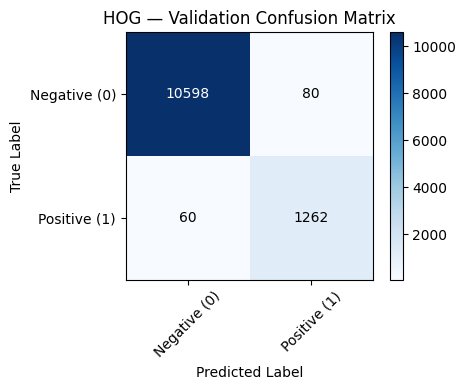


📊 Test Set — HOG
   Accuracy  : 98.80%
   Precision : 94.56%
   Recall    : 94.89%
   F1-Score  : 94.72%
   TP=1077  TN=8803  FP=62  FN=58


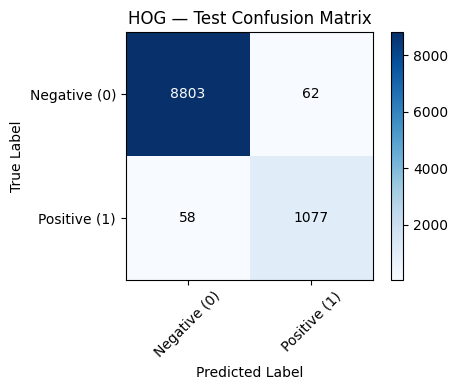


⚖️  Baseline        : 88.65%
   HOG Test Acc   : 98.80%
   Improvement    : +10.15%

✅ HOG cell complete!


In [17]:
# ============================================================
# Decision Tree — Feature Method: HOG        cell 8
# ============================================================

from preprocessing.preprocess import preprocess

# Load data with HOG feature extraction
X_train, X_val, X_test, y_train, y_val, y_test = preprocess(
    feature_method='hog',
    binary=True,
    positive_class=1
)

print(f"Training set  : {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set      : {X_test.shape}")

# ── Train ──────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  TRAINING — HOG Features")
print("=" * 55)

t0       = time.time()
tree_hog = build_tree(X_train, y_train, max_depth=15, min_samples_split=10)
t1       = time.time()
print(f"✅ Tree built in {(t1 - t0) / 60:.1f} minutes!")

# ── Evaluate ───────────────────────────────────────────────
print("\n" + "=" * 55)
print("  EVALUATION — HOG Features")
print("=" * 55)

y_val_pred_hog  = predict(tree_hog, X_val)
y_test_pred_hog = predict(tree_hog, X_test)

val_metrics_hog  = compute_metrics(y_val,  y_val_pred_hog)
test_metrics_hog = compute_metrics(y_test, y_test_pred_hog)

print_metrics(val_metrics_hog,  "Validation Set — HOG")
plot_confusion_matrix(val_metrics_hog,  title="HOG — Validation Confusion Matrix")

print_metrics(test_metrics_hog, "Test Set — HOG")
plot_confusion_matrix(test_metrics_hog, title="HOG — Test Confusion Matrix")

baseline = np.mean(y_test == 0) * 100
print(f"\n⚖️  Baseline        : {baseline:.2f}%")
print(f"   HOG Test Acc   : {test_metrics_hog['accuracy'] * 100:.2f}%")
print(f"   Improvement    : +{test_metrics_hog['accuracy'] * 100 - baseline:.2f}%")

print("\n✅ HOG cell complete!")

   DECISION TREE — FEATURE METHOD COMPARISON (Test Set)
Method         Accuracy  Precision     Recall         F1
------------------------------------------------------------
Flatten          98.99%     95.51%     95.59%     95.55%
PCA              99.22%      96.65%     96.48%     96.56%
HOG              98.80%      94.56%     94.89%     94.72%


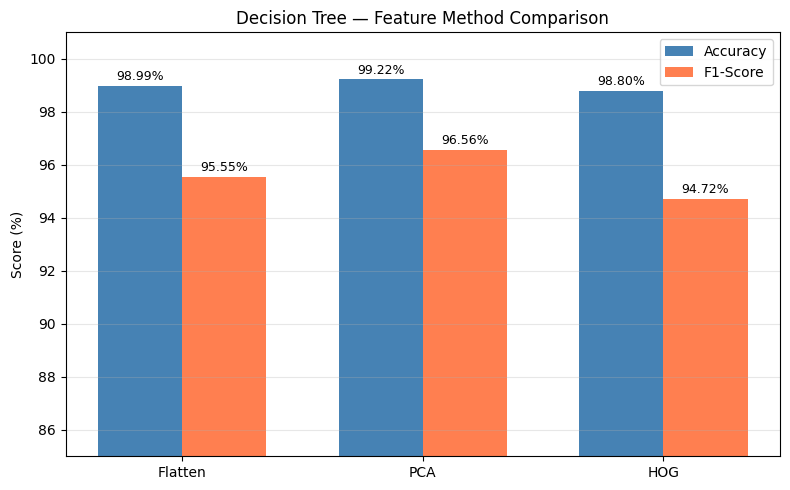


✅ Cell 9 complete — Comparison done!


In [18]:
# ============================================================
# Cell 9: Feature Method Comparison — Flatten vs PCA vs HOG
# ============================================================

print("=" * 60)
print("   DECISION TREE — FEATURE METHOD COMPARISON (Test Set)")
print("=" * 60)
print(f"{'Method':<12} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 60)
print(f"{'Flatten':<12} {test_metrics_flat['accuracy']*100:>9.2f}% {test_metrics_flat['precision']*100:>9.2f}% {test_metrics_flat['recall']*100:>9.2f}% {test_metrics_flat['f1']*100:>9.2f}%")
print(f"{'PCA':<12} {test_metrics_pca['accuracy']*100:>9.2f}%  {test_metrics_pca['precision']*100:>9.2f}% {test_metrics_pca['recall']*100:>9.2f}% {test_metrics_pca['f1']*100:>9.2f}%")
print(f"{'HOG':<12} {test_metrics_hog['accuracy']*100:>9.2f}%  {test_metrics_hog['precision']*100:>9.2f}% {test_metrics_hog['recall']*100:>9.2f}% {test_metrics_hog['f1']*100:>9.2f}%")
print("=" * 60)

# ── Bar chart ──────────────────────────────────────────────
methods    = ['Flatten', 'PCA', 'HOG']
accuracies = [test_metrics_flat['accuracy'],
              test_metrics_pca['accuracy'],
              test_metrics_hog['accuracy']]
f1_scores  = [test_metrics_flat['f1'],
              test_metrics_pca['f1'],
              test_metrics_hog['f1']]

x     = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, [a * 100 for a in accuracies], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, [f * 100 for f in f1_scores],  width, label='F1-Score', color='coral')

ax.set_ylabel('Score (%)')
ax.set_title('Decision Tree — Feature Method Comparison')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylim(85, 101)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✅ Cell 9 complete — Comparison done!")

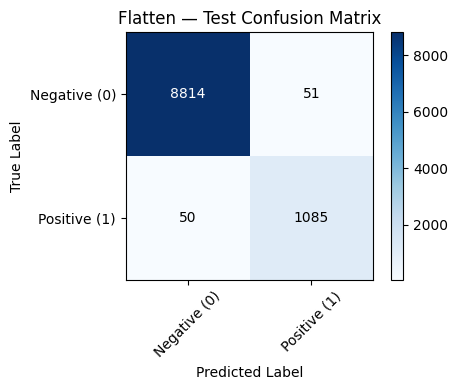

✅ Saved: decision_tree_flatten_confusion_matrix.png


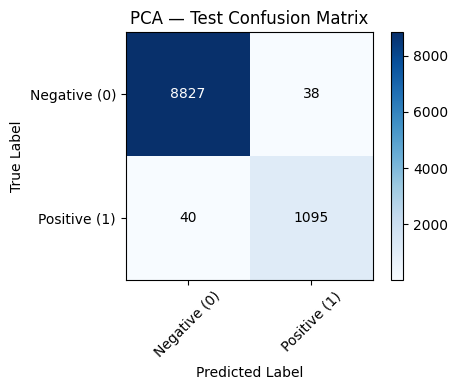

✅ Saved: decision_tree_pca_confusion_matrix.png


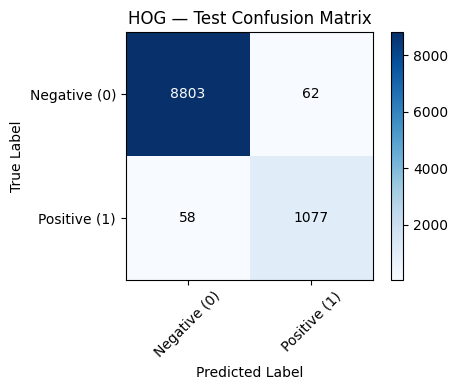

✅ Saved: decision_tree_hog_confusion_matrix.png


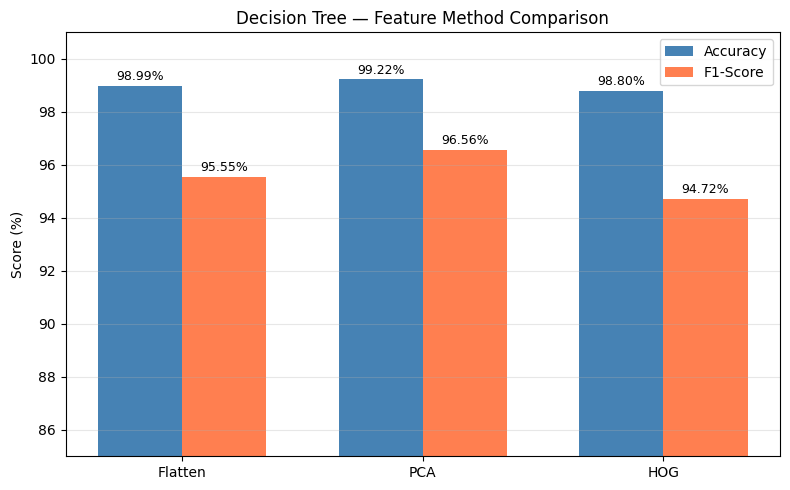

✅ Saved: decision_tree_comparison.png
✅ Saved: decision_tree_results.txt

✅ Cell 10 complete — All results saved!


In [19]:
# ============================================================
# Cell 10: Save All Results to /results folder
# ============================================================

import os
results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

# ── 1. Save Flatten Confusion Matrix ───────────────────────
cm = np.array([[val_metrics_flat['TN'], val_metrics_flat['FP']],
               [val_metrics_flat['FN'], val_metrics_flat['TP']]])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(np.array([[test_metrics_flat['TN'], test_metrics_flat['FP']],
                          [test_metrics_flat['FN'], test_metrics_flat['TP']]]),
               interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)
classes = ['Negative (0)', 'Positive (1)']
ax.set_xticks([0,1]); ax.set_xticklabels(classes, rotation=45)
ax.set_yticks([0,1]); ax.set_yticklabels(classes)
cm_flat = np.array([[test_metrics_flat['TN'], test_metrics_flat['FP']],
                    [test_metrics_flat['FN'], test_metrics_flat['TP']]])
thresh = cm_flat.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_flat[i,j]), ha='center', va='center',
                color='white' if cm_flat[i,j] > thresh else 'black')
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
ax.set_title('Flatten — Test Confusion Matrix')
plt.tight_layout()
plt.savefig(f"{results_dir}/decision_tree_flatten_confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: decision_tree_flatten_confusion_matrix.png")

# ── 2. Save PCA Confusion Matrix ───────────────────────────
cm_pca = np.array([[test_metrics_pca['TN'], test_metrics_pca['FP']],
                   [test_metrics_pca['FN'], test_metrics_pca['TP']]])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_pca, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)
ax.set_xticks([0,1]); ax.set_xticklabels(classes, rotation=45)
ax.set_yticks([0,1]); ax.set_yticklabels(classes)
thresh = cm_pca.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_pca[i,j]), ha='center', va='center',
                color='white' if cm_pca[i,j] > thresh else 'black')
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
ax.set_title('PCA — Test Confusion Matrix')
plt.tight_layout()
plt.savefig(f"{results_dir}/decision_tree_pca_confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: decision_tree_pca_confusion_matrix.png")

# ── 3. Save HOG Confusion Matrix ───────────────────────────
cm_hog = np.array([[test_metrics_hog['TN'], test_metrics_hog['FP']],
                   [test_metrics_hog['FN'], test_metrics_hog['TP']]])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_hog, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)
ax.set_xticks([0,1]); ax.set_xticklabels(classes, rotation=45)
ax.set_yticks([0,1]); ax.set_yticklabels(classes)
thresh = cm_hog.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_hog[i,j]), ha='center', va='center',
                color='white' if cm_hog[i,j] > thresh else 'black')
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
ax.set_title('HOG — Test Confusion Matrix')
plt.tight_layout()
plt.savefig(f"{results_dir}/decision_tree_hog_confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: decision_tree_hog_confusion_matrix.png")

# ── 4. Save Comparison Bar Chart ───────────────────────────
methods    = ['Flatten', 'PCA', 'HOG']
accuracies = [test_metrics_flat['accuracy'],
              test_metrics_pca['accuracy'],
              test_metrics_hog['accuracy']]
f1_scores  = [test_metrics_flat['f1'],
              test_metrics_pca['f1'],
              test_metrics_hog['f1']]

x     = np.arange(len(methods))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, [a*100 for a in accuracies], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, [f*100 for f in f1_scores],  width, label='F1-Score', color='coral')
ax.set_ylabel('Score (%)'); ax.set_title('Decision Tree — Feature Method Comparison')
ax.set_xticks(x); ax.set_xticklabels(methods)
ax.set_ylim(85, 101); ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(f"{results_dir}/decision_tree_comparison.png", dpi=150)
plt.show()
print("✅ Saved: decision_tree_comparison.png")

# ── 5. Save Results TXT ────────────────────────────────────
with open(f"{results_dir}/decision_tree_results.txt", "w") as f:
    f.write("=" * 60 + "\n")
    f.write("  DECISION TREE — PHASE 1 RESULTS SUMMARY\n")
    f.write("=" * 60 + "\n\n")

    f.write("Hyperparameters:\n")
    f.write("  max_depth         : 15\n")
    f.write("  min_samples_split : 10\n")
    f.write("  criterion         : Gini Index\n")
    f.write("  training samples  : 48000\n\n")

    f.write("-" * 60 + "\n")
    f.write("FLATTEN FEATURES (784 features)\n")
    f.write("-" * 60 + "\n")
    f.write(f"  Accuracy  : {test_metrics_flat['accuracy']*100:.2f}%\n")
    f.write(f"  Precision : {test_metrics_flat['precision']*100:.2f}%\n")
    f.write(f"  Recall    : {test_metrics_flat['recall']*100:.2f}%\n")
    f.write(f"  F1-Score  : {test_metrics_flat['f1']*100:.2f}%\n")
    f.write(f"  TP={test_metrics_flat['TP']}  TN={test_metrics_flat['TN']}  FP={test_metrics_flat['FP']}  FN={test_metrics_flat['FN']}\n\n")

    f.write("-" * 60 + "\n")
    f.write("PCA FEATURES (50 components)\n")
    f.write("-" * 60 + "\n")
    f.write(f"  Accuracy  : {test_metrics_pca['accuracy']*100:.2f}%\n")
    f.write(f"  Precision : {test_metrics_pca['precision']*100:.2f}%\n")
    f.write(f"  Recall    : {test_metrics_pca['recall']*100:.2f}%\n")
    f.write(f"  F1-Score  : {test_metrics_pca['f1']*100:.2f}%\n")
    f.write(f"  TP={test_metrics_pca['TP']}  TN={test_metrics_pca['TN']}  FP={test_metrics_pca['FP']}  FN={test_metrics_pca['FN']}\n\n")

    f.write("-" * 60 + "\n")
    f.write("HOG FEATURES\n")
    f.write("-" * 60 + "\n")
    f.write(f"  Accuracy  : {test_metrics_hog['accuracy']*100:.2f}%\n")
    f.write(f"  Precision : {test_metrics_hog['precision']*100:.2f}%\n")
    f.write(f"  Recall    : {test_metrics_hog['recall']*100:.2f}%\n")
    f.write(f"  F1-Score  : {test_metrics_hog['f1']*100:.2f}%\n")
    f.write(f"  TP={test_metrics_hog['TP']}  TN={test_metrics_hog['TN']}  FP={test_metrics_hog['FP']}  FN={test_metrics_hog['FN']}\n\n")

    f.write("=" * 60 + "\n")
    f.write("BEST METHOD: PCA\n")
    f.write(f"  Best Accuracy : {test_metrics_pca['accuracy']*100:.2f}%\n")
    f.write(f"  Best F1-Score : {test_metrics_pca['f1']*100:.2f}%\n")
    f.write("=" * 60 + "\n")

print("✅ Saved: decision_tree_results.txt")
print("\n✅ Cell 10 complete — All results saved!")